# Literature
<img src="https://www.researchgate.net/profile/Md-Nurul-Huda-2/publication/325924015/figure/fig4/AS:640254147043330@1529659892721/The-energy-dispersion-in-a-honeycomb-lattice-a-The-valence-and-conduction-bands-of.png" alt="A Cat" width="800">


# Model

In [2]:
from acceptor_TI import Problem

data_path = "../../acceptor_TI/data/"
file_name = "honeycomb.json"

problem = Problem(data_path=data_path, file_name=file_name)

### s orbitals

In [3]:
location = "bulk"
problem.setup(
    N_r = 10, # size of lattice in real space
    N_k = 200, # reciprocal space discretization
    location = location
)

Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.


In [4]:
problem.model_options.solve_connectivity = True

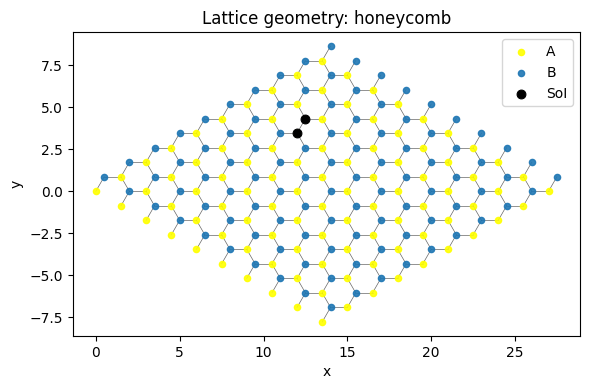

In [5]:
tb = problem.hamiltonian[location]["tight_binding"]
problem.geometry.plot_lattice(
    sites_of_interest=tb.sublattice_idxs
    )

In [6]:
problem.run(
    acceptor=False,
    H_type="reciprocal_space"
)

Calculating 'Bulk' eigenvalues...


'Bulk' Eigenvalues - Done.


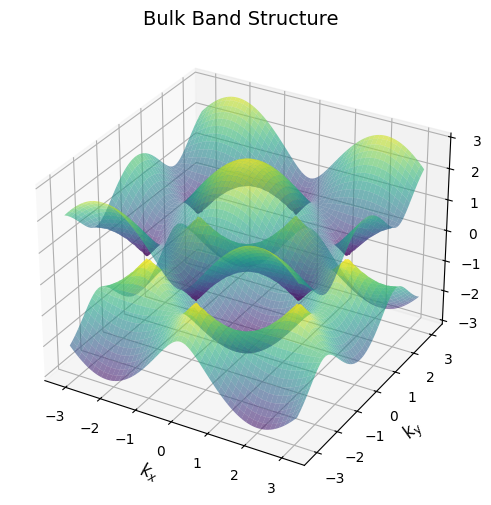

In [7]:
problem.plot(plot_type="dispersion", location=location)

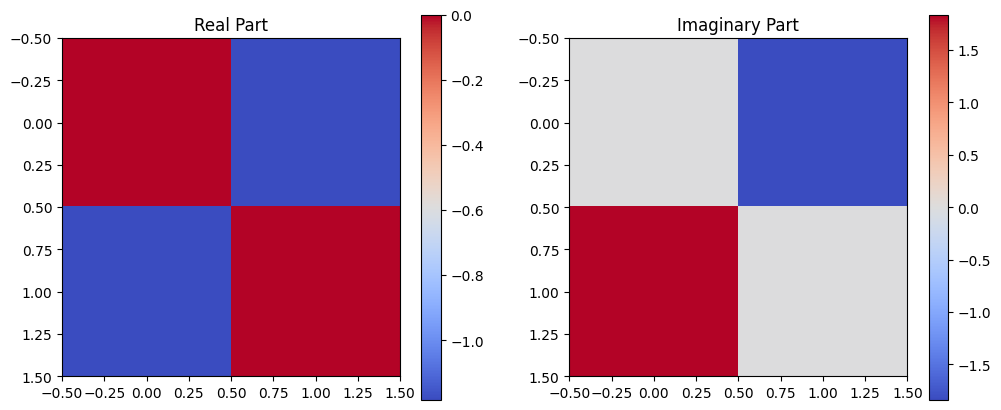

In [8]:
tb = problem.hamiltonian["bulk"]["tight_binding"]
g = problem.geometry
k_x, k_y = g.kx_bulk, g.ky_bulk
k = [k_x[g.N_r-1], k_y[g.N_r-1]]
H_k = tb._fourier_transform(g, k)
tb._visualise_matrix(H_k)